### Overview

Zo všetkých variantov sa ako najlepší ukázal model XGBoost s výberom hyperparametrov a optimalizáciou klasifikačného prahu.
Naopak najhoršie výsledky dosiahla základná model, ktorá nevyužíva optimalizáciu parametrov a má nižšiu výkonnosť.
Porovnanie výsledkov ukazuje, že s rastom hodnoty σ výkonnosť modelu XGBoost stabilne stúpa.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix)

In [2]:
TW_500= pd.read_csv(
    "../classification/Twitter/Relative_labeling/sigma=500/Twitter-Relative-Sigma-500.data",
    sep=",",
    header=None
)

TW_1000= pd.read_csv(
    "../classification/Twitter/Relative_labeling/sigma=1000/Twitter-Relative-Sigma-1000.data",
    sep=",",
    header=None
)
TW_1500= pd.read_csv(
    "../classification/Twitter/Relative_labeling/sigma=1500/Twitter-Relative-Sigma-1500.data",
    sep=",",
    header=None
)
groups = ["NCD", 'AI', 'AS(NA)', 'BL',
         'NAC', 'AS(NAC)', 'CS', 'AT', 'NA','ADL', 'NAD']

columns = []
for group in groups:
    for t in range(7):
        columns.append(f"{group}_{t}")

columns.append("label") 

TW_500.columns = columns
TW_1000.columns = columns
TW_1500.columns = columns


### 500

In [3]:
X = TW_500.drop(columns=['label'])
y = TW_500['label']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, stratify=y,random_state=42)

In [4]:
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss').fit(X_train, y_train)


y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

print("1. Baseline XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

1. Baseline XGBoost
Accuracy: 0.9815578139435719
Precision: 0.6998050682261209
Recall: 0.4958563535911602
F1-score: 0.5804365400161682
ROC-AUC: 0.9652705767755909
Confusion Matrix:
[[27264   154]
 [  365   359]]


### 2. XGBoost with Grid Search

In [4]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

grid_search_xgb = GridSearchCV( xgb,param_grid,cv=5,scoring='f1',n_jobs=-1).fit(X_train, y_train)

best_xgb = grid_search_xgb.best_estimator_

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:,1]

print("2. XGBoost with Grid Search")
print("Best parameters:", grid_search_xgb.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

2. XGBoost with Grid Search
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
Accuracy: 0.9822329614099922
Precision: 0.7343096234309623
Recall: 0.48480662983425415
F1-score: 0.5840266222961731
ROC-AUC: 0.9698975075453516


### 3. XGBoost with scale_pos_weight and Grid Search

In [8]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 37.869129834254146


In [9]:
xgb = XGBClassifier(random_state=42,use_label_encoder=False,eval_metric='logloss',scale_pos_weight=scale_pos_weight)

grid_search_xgb_weighted = GridSearchCV(xgb,param_grid,cv=5,scoring='f1',n_jobs=-1).fit(X_train, y_train)


best_xgb_weighted = grid_search_xgb_weighted.best_estimator_

y_pred = best_xgb_weighted.predict(X_test)
y_prob = best_xgb_weighted.predict_proba(X_test)[:,1]



print("3. XGBoost with scale_pos_weight and Grid Search")
print("Best parameters:", grid_search_xgb_weighted.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

3. XGBoost with scale_pos_weight and Grid Search
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'subsample': 1.0}
Accuracy: 0.9780044062255703
Precision: 0.5668789808917197
Recall: 0.6146408839779005
F1-score: 0.5897945659377071
ROC-AUC: 0.9660140039873794
Confusion Matrix:
[[27078   340]
 [  279   445]]


### XGBoost Random Search

In [10]:

xgb = XGBClassifier(random_state=42,eval_metric='logloss',use_label_encoder=False)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

random_search = RandomizedSearchCV(xgb, param_distributions=param_dist, n_iter=30,  scoring='f1', cv=5,verbose=1,random_state=42,n_jobs=-1).fit(X_train, y_train)

best_xgb_rand = random_search.best_estimator_

print("Best parameters:", random_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.9}


In [11]:
y_pred = best_xgb_rand.predict(X_test)
y_prob = best_xgb_rand.predict_proba(X_test)[:,1]

print("XGBoost Random Search")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


XGBoost Random Search
Accuracy: 0.9836187904200128
Precision: 0.7864923747276689
Recall: 0.4986187845303867
F1: 0.610312764158918
ROC-AUC: 0.9691163737255317


In [12]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.3, 0.7, 0.01)

best_f1 = 0
best_t = 0

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)

Best threshold: 0.36000000000000004
Best F1: 0.6240601503759399


In [3]:
import pandas as pd

xgb_500 = [
    {"Model": "XGB baseline", "Accuracy": 0.98156, "Precision": 0.6998, "Recall": 0.4959, "F1": 0.5804, "ROC-AUC": 0.9653},
    {"Model": "XGB grid", "Accuracy": 0.98223, "Precision": 0.7343, "Recall": 0.4848, "F1": 0.5840, "ROC-AUC": 0.9699},
    {"Model": "XGB balanced", "Accuracy": 0.97800, "Precision": 0.5669, "Recall": 0.6146, "F1": 0.5898, "ROC-AUC": 0.9660},
    {"Model": "XGB random", "Accuracy": 0.98362, "Precision": 0.7865, "Recall": 0.4986, "F1": 0.6103, "ROC-AUC": 0.9691},
    {"Model": "XGB + threshold", "Accuracy": None, "Precision": None, "Recall": None, "F1": 0.6241, "ROC-AUC": None}
]

df_xgb_500 = pd.DataFrame(xgb_500)
df_xgb_500

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGB baseline,0.98156,0.6998,0.4959,0.5804,0.9653
1,XGB grid,0.98223,0.7343,0.4848,0.5840,0.9699
2,XGB balanced,0.97800,0.5669,0.6146,0.5898,0.9660
3,XGB random,0.98362,0.7865,0.4986,0.6103,0.9691
4,XGB + threshold,NaN,NaN,NaN,0.6241,NaN


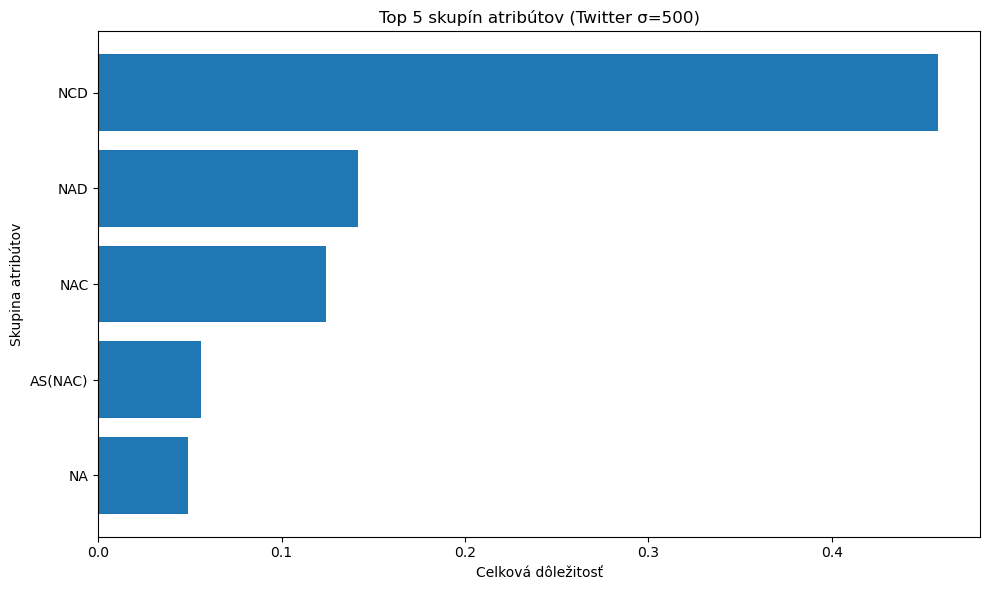

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

importances = best_xgb.feature_importances_
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feat_imp['base_feature'] = feat_imp['feature'].apply(lambda x: x.rsplit('_', 1)[0])

grouped_importance = feat_imp.groupby('base_feature')['importance'].sum().reset_index()
grouped_importance = grouped_importance.sort_values(by='importance', ascending=False)
top_grouped = grouped_importance.head(5)

plt.figure(figsize=(10, 6))
plt.barh(top_grouped['base_feature'], top_grouped['importance'])
plt.gca().invert_yaxis()

# Словацький заголовок для Twitter
plt.title("Top 5 skupín atribútov (Twitter σ=500)")
plt.xlabel("Celková dôležitosť") 
plt.ylabel("Skupina atribútov")

plt.tight_layout()
plt.show()

In [15]:
confusion_matrix(y_test, y_pred)

array([[27320,    98],
       [  363,   361]])

### 1000

In [6]:
X = TW_1000.drop(columns=['label'])
y = TW_1000['label']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, stratify=y,random_state=42)

In [21]:
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss').fit(X_train, y_train)


y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

print("1. Baseline XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

1. Baseline XGBoost
Accuracy: 0.9933551275673371
Precision: 0.6142857142857143
Recall: 0.548936170212766
F1-score: 0.5797752808988764
ROC-AUC: 0.9273633016653337
Confusion Matrix:
[[27826    81]
 [  106   129]]


### 2. XGBoost with Grid Search

In [7]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

grid_search_xgb = GridSearchCV( xgb,param_grid,cv=5,scoring='f1',n_jobs=-1).fit(X_train, y_train)

best_xgb = grid_search_xgb.best_estimator_

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:,1]

print("2. XGBoost with Grid Search")
print("Best parameters:", grid_search_xgb.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

2. XGBoost with Grid Search
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 0.9948475588088977
Precision: 0.7528089887640449
Recall: 0.5702127659574469
F1-score: 0.648910411622276
ROC-AUC: 0.982874501859901


### 3. XGBoost with scale_pos_weight and Grid Search

In [23]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 118.49575371549894


In [24]:
xgb = XGBClassifier(random_state=42,use_label_encoder=False,eval_metric='logloss',scale_pos_weight=scale_pos_weight)

grid_search_xgb_weighted = GridSearchCV(xgb,param_grid,cv=5,scoring='f1',n_jobs=-1).fit(X_train, y_train)


best_xgb_weighted = grid_search_xgb_weighted.best_estimator_

y_pred = best_xgb_weighted.predict(X_test)
y_prob = best_xgb_weighted.predict_proba(X_test)[:,1]



print("3. XGBoost with scale_pos_weight and Grid Search")
print("Best parameters:", grid_search_xgb_weighted.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

3. XGBoost with scale_pos_weight and Grid Search
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 0.9940658091109373
Precision: 0.6370967741935484
Recall: 0.6723404255319149
F1-score: 0.6542443064182195
ROC-AUC: 0.9830957534485742
Confusion Matrix:
[[27817    90]
 [   77   158]]


### XGBoost Random Search

In [25]:

xgb = XGBClassifier(random_state=42,eval_metric='logloss',use_label_encoder=False)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

random_search = RandomizedSearchCV(xgb, param_distributions=param_dist, n_iter=30,  scoring='f1', cv=5,verbose=1,random_state=42,n_jobs=-1).fit(X_train, y_train)

best_xgb_rand = random_search.best_estimator_

print("Best parameters:", random_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'subsample': 0.9, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.8}


In [26]:
y_pred = best_xgb_rand.predict(X_test)
y_prob = best_xgb_rand.predict_proba(X_test)[:,1]

print("XGBoost Random Search")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


XGBoost Random Search
Accuracy: 0.9947054225001777
Precision: 0.7216494845360825
Recall: 0.5957446808510638
F1: 0.6526806526806527
ROC-AUC: 0.9800021195017798


In [27]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.3, 0.7, 0.01)

best_f1 = 0
best_t = 0

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)

Best threshold: 0.33
Best F1: 0.6722689075630253


In [5]:
import pandas as pd

xgb_1000 = [
    {"Model": "XGB baseline", "Accuracy": 0.99336, "Precision": 0.6143, "Recall": 0.5489, "F1": 0.5798, "ROC-AUC": 0.9274},
    {"Model": "XGB grid", "Accuracy": 0.99485, "Precision": 0.7528, "Recall": 0.5702, "F1": 0.6489, "ROC-AUC": 0.9829},
    {"Model": "XGB balanced", "Accuracy": 0.99407, "Precision": 0.6371, "Recall": 0.6723, "F1": 0.6542, "ROC-AUC": 0.9831},
    {"Model": "XGB random", "Accuracy": 0.99471, "Precision": 0.7216, "Recall": 0.5957, "F1": 0.6527, "ROC-AUC": 0.9800},
    {"Model": "XGB + threshold", "Accuracy": None, "Precision": None, "Recall": None, "F1": 0.6723, "ROC-AUC": None}
]

df_xgb_1000 = pd.DataFrame(xgb_1000)
df_xgb_1000

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGB baseline,0.99336,0.6143,0.5489,0.5798,0.9274
1,XGB grid,0.99485,0.7528,0.5702,0.6489,0.9829
2,XGB balanced,0.99407,0.6371,0.6723,0.6542,0.9831
3,XGB random,0.99471,0.7216,0.5957,0.6527,0.9800
4,XGB + threshold,NaN,NaN,NaN,0.6723,NaN


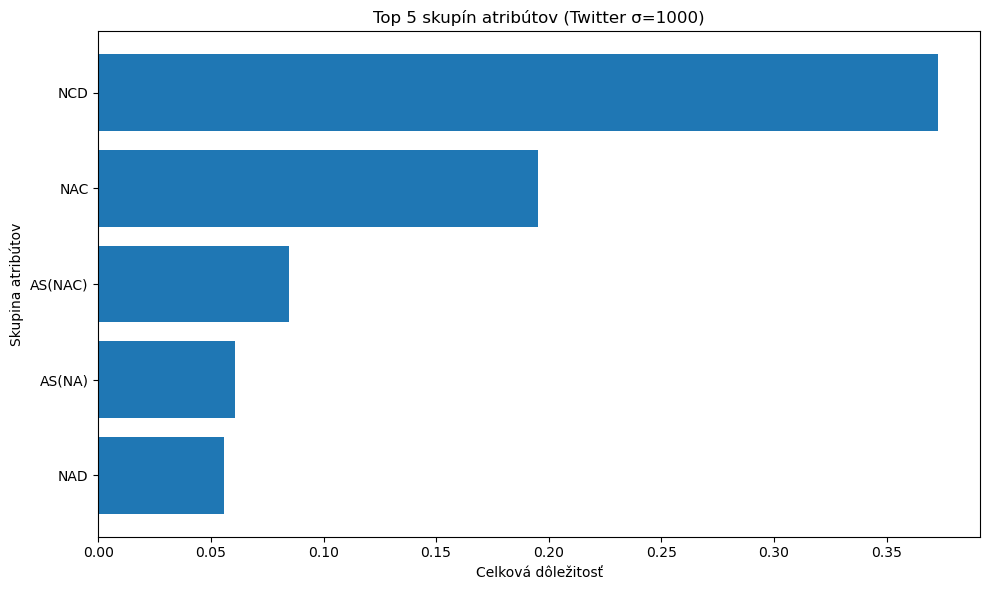

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

importances = best_xgb.feature_importances_
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feat_imp['base_feature'] = feat_imp['feature'].apply(lambda x: x.rsplit('_', 1)[0])

grouped_importance = feat_imp.groupby('base_feature')['importance'].sum().reset_index()
grouped_importance = grouped_importance.sort_values(by='importance', ascending=False)
top_grouped = grouped_importance.head(5)

plt.figure(figsize=(10, 6))
plt.barh(top_grouped['base_feature'], top_grouped['importance'])
plt.gca().invert_yaxis()

# Словацький заголовок для Twitter
plt.title("Top 5 skupín atribútov (Twitter σ=1000)")
plt.xlabel("Celková dôležitosť") 
plt.ylabel("Skupina atribútov")

plt.tight_layout()
plt.show()

### 15000

In [9]:
X = TW_1500.drop(columns=['label'])
y = TW_1500['label']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, stratify=y,random_state=42)

### Baseline XGBoost

In [31]:
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss').fit(X_train, y_train)


y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:,1]

print("1. Baseline XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

1. Baseline XGBoost
Accuracy: 0.9969796034396987
Precision: 0.5730337078651685
Recall: 0.5204081632653061
F1-score: 0.5454545454545454
ROC-AUC: 0.9383701704901044
Confusion Matrix:
[[28006    38]
 [   47    51]]


### 2. XGBoost with Grid Search

In [10]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

grid_search_xgb = GridSearchCV( xgb,param_grid,cv=5,scoring='f1',n_jobs=-1).fit(X_train, y_train)

best_xgb = grid_search_xgb.best_estimator_

y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:,1]

print("2. XGBoost with Grid Search")
print("Best parameters:", grid_search_xgb.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

2. XGBoost with Grid Search
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Accuracy: 0.9979390235235591
Precision: 0.7380952380952381
Recall: 0.6326530612244898
F1-score: 0.6813186813186813
ROC-AUC: 0.9942310043401186


### 3. XGBoost with scale_pos_weight and Grid Search

In [35]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 287.62820512820514


In [36]:
xgb = XGBClassifier(random_state=42,use_label_encoder=False,eval_metric='logloss',scale_pos_weight=scale_pos_weight)

grid_search_xgb_weighted = GridSearchCV(xgb,param_grid,cv=5,scoring='f1',n_jobs=-1).fit(X_train, y_train)


best_xgb_weighted = grid_search_xgb_weighted.best_estimator_

y_pred = best_xgb_weighted.predict(X_test)
y_prob = best_xgb_weighted.predict_proba(X_test)[:,1]



print("3. XGBoost with scale_pos_weight and Grid Search")
print("Best parameters:", grid_search_xgb_weighted.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

3. XGBoost with scale_pos_weight and Grid Search
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 0.9974770805202189
Precision: 0.6173913043478261
Recall: 0.7244897959183674
F1-score: 0.6666666666666666
ROC-AUC: 0.99292292869223
Confusion Matrix:
[[28000    44]
 [   27    71]]


### XGBoost Random Search

In [38]:

xgb = XGBClassifier(random_state=42,eval_metric='logloss',use_label_encoder=False)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

random_search = RandomizedSearchCV(xgb, param_distributions=param_dist, n_iter=30,  scoring='f1', cv=5,verbose=1,random_state=42,n_jobs=-1).fit(X_train, y_train)

best_xgb_rand = random_search.best_estimator_

print("Best parameters:", random_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.9}


In [39]:
y_pred = best_xgb_rand.predict(X_test)
y_prob = best_xgb_rand.predict_proba(X_test)[:,1]

print("XGBoost Random Search")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


XGBoost Random Search
Accuracy: 0.997619216828939
Precision: 0.7183098591549296
Recall: 0.5204081632653061
F1: 0.6035502958579881
ROC-AUC: 0.9930058887055037


In [40]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.3, 0.7, 0.01)

best_f1 = 0
best_t = 0

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Best F1:", best_f1)

Best threshold: 0.32
Best F1: 0.6868686868686869


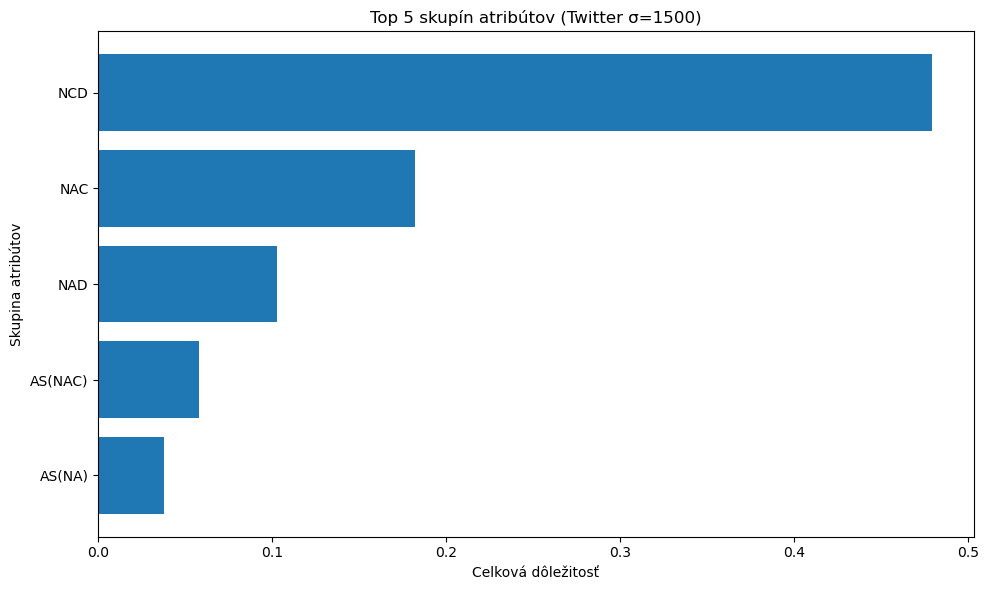

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

importances = best_xgb.feature_importances_
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feat_imp['base_feature'] = feat_imp['feature'].apply(lambda x: x.rsplit('_', 1)[0])

grouped_importance = feat_imp.groupby('base_feature')['importance'].sum().reset_index()
grouped_importance = grouped_importance.sort_values(by='importance', ascending=False)
top_grouped = grouped_importance.head(5)

plt.figure(figsize=(10, 6))
plt.barh(top_grouped['base_feature'], top_grouped['importance'])
plt.gca().invert_yaxis()

# Словацький заголовок для Twitter
plt.title("Top 5 skupín atribútov (Twitter σ=1500)")
plt.xlabel("Celková dôležitosť") 
plt.ylabel("Skupina atribútov")

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd

xgb_1500 = [
    {"Model": "XGB baseline", "Accuracy": 0.99698, "Precision": 0.5730, "Recall": 0.5204, "F1": 0.5455, "ROC-AUC": 0.9384},
    {"Model": "XGB grid", "Accuracy": 0.99794, "Precision": 0.7381, "Recall": 0.6327, "F1": 0.6813, "ROC-AUC": 0.9942},
    {"Model": "XGB balanced", "Accuracy": 0.99748, "Precision": 0.6174, "Recall": 0.7245, "F1": 0.6667, "ROC-AUC": 0.9929},
    {"Model": "XGB random", "Accuracy": 0.99762, "Precision": 0.7183, "Recall": 0.5204, "F1": 0.6036, "ROC-AUC": 0.9930},
    {"Model": "XGB + threshold", "Accuracy": None, "Precision": None, "Recall": None, "F1": 0.6869, "ROC-AUC": None}
]

df_xgb_1500 = pd.DataFrame(xgb_1500)
df_xgb_1500

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGB baseline,0.99698,0.5730,0.5204,0.5455,0.9384
1,XGB grid,0.99794,0.7381,0.6327,0.6813,0.9942
2,XGB balanced,0.99748,0.6174,0.7245,0.6667,0.9929
3,XGB random,0.99762,0.7183,0.5204,0.6036,0.9930
4,XGB + threshold,NaN,NaN,NaN,0.6869,NaN
